In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('./..')
from cbx.dynamics import CBO, CBS
from cbx.scheduler import multiply
from cbx.utils.termination import max_eval_term
from cbx.noise import covariance_noise
import numpy as np
import matplotlib.pyplot as plt
from experimentUtils import check_unit_weight_estimates
from CBO_utils import PreconditionedFunction, RotFunCBO, RotNoiseCBO, SplitDimCBO, Rot_fun, estimate_Q
from problems import RastriginProblem

## Set up the problem

In [2]:
np.random.seed(211)
d   = 2
P   = RastriginProblem(d=d)
#f   = P.generate_rotated()['objective']
f   = P.generate_transformed(quasi_orth=True, perturb = 5.)['objective']
N   = 10
x0  = P.sample(1, N)

## Run CBO on standard Rastrigin function

In [3]:
ckwargs = {
    'dt':0.05, 'sigma':5., 'lamda':1., 'max_it':80,
    'track_args': {'names':['x', 'consensus', 'energy']},
    'alpha':1e2, 'verbosity':0, 'seed': 42
}
print_summary = lambda dyn: print('Finished with energy ', dyn.f(dyn.best_particle))
dyn = CBO(f.f,x=x0.copy(), noise = 'anisotropic', **ckwargs)
dyn.optimize()

print_summary(dyn)

Finished with energy  [[0.99495999]]


## Run CBO on rotated Rastrigin

In [4]:
dyn_f_rot = CBO(f,x=x0.copy(), noise = 'anisotropic', **ckwargs)
dyn_f_rot.optimize()

print_summary(dyn_f_rot)

Finished with energy  [[1.98992625]]


## Run CBO on rotated Rastrigin with isotropic noise

In [5]:
dyn_iso = CBO(f, x=x0.copy(), noise = 'isotropic', **(ckwargs | {'sigma':2.}))
dyn_iso.optimize()
print_summary(dyn_iso)

Finished with energy  [[3.54443175e-06]]


## Run CBS on rotated Rastrigin

In [6]:
#noise = covariance_noise(mode = 'sampling')
dyn_rot_CBS = CBS(f, x=x0.copy(), **(ckwargs | {'sigma':2., 'alpha':0.01, 'dt':0.01, 'max_it':1000}), scheme='exponential', mode='optimization')
dyn_rot_CBS.optimize()
print_summary(dyn_rot_CBS)

Finished with energy  [[0.04761908]]


## Plot results

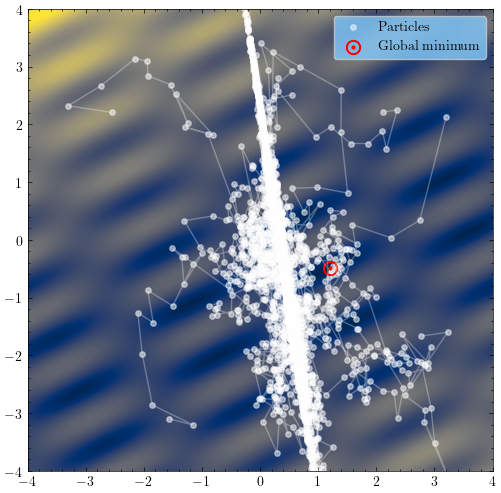

In [7]:
from cbx.plotting import PlotDynamicHistory
import scienceplots
plt.style.use('science')
fig, ax = plt.subplots(1,1, figsize=(6,6))

rot, noise = True, 'CBS'
dyn_plot = dyn_iso if noise == 'iso' else (dyn_rot_CBS if noise == 'CBS' else dyn_f_rot if rot else dyn)
pl = PlotDynamicHistory(
    dyn_plot, objective_args={'x_min':-4, 'x_max':4, 'cmap':'cividis','levels':150, 'num_pts':200},
    ax=ax)
pl.plot_objective()
x = np.array(dyn_plot.history['x'])
ts = np.arange(30, x.shape[0], 3)
ps = np.arange(30, x.shape[0], 3)
for i in range(N): 
    plt.plot(x[ps,0,i,0], x[ps,0,i,1], color='w', alpha=0.3)
    plt.scatter(x[ts,0,i,0], x[ts,0,i,1], color='w', alpha=0.5, s=15, label='Particles' if i == 0 else None)

glob_min = P.minimum if rot else f.f.b
plt.scatter(glob_min[0], glob_min[1], color='red', label='Global minimum', marker='$\odot$', s=100)
plt.legend(frameon=True, facecolor='xkcd:sky')
plt.savefig(f'figs/CBO_2d_{"rot_" if rot else "" }{noise}.png')

## Test CMA-ES

In [87]:
import cma

x0_mean = x0.mean(axis=(0, 1))
sigma0 = x0.std(axis=(0, 1)).mean()

history_cma = []
best_x, best_f = None, np.inf
n_restarts = 8
for restart in range(n_restarts):
    es = cma.CMAEvolutionStrategy(x0_mean, sigma0, {
        'popsize': N, 'seed': 2 + restart, 'verbose': -9,
    })
    while not es.stop():
        solutions = es.ask()
        history_cma.append(np.array(solutions))
        es.tell(solutions, f(np.array(solutions)))
    if es.result.fbest < best_f:
        best_f, best_x = es.result.fbest, es.result.xbest

x_cma = np.array(history_cma)[:, None, :, :]   # (n_generations, 1, N, d)
print('Finished with energy ', best_f)

Finished with energy  0.0


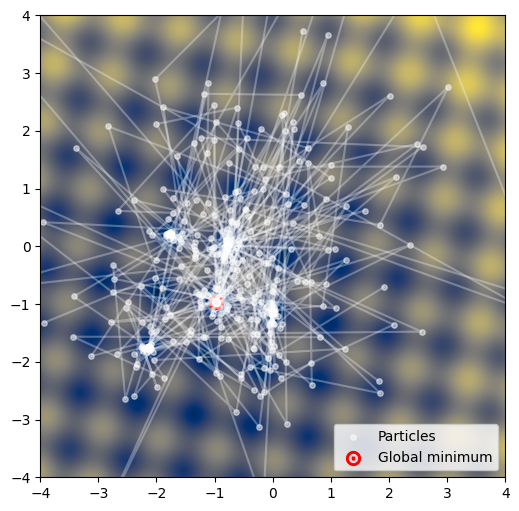

In [88]:
from cbx.plotting import contour_2D

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
contour_2D(f, ax=ax, d=d, x_min=-4, x_max=4, cmap='cividis', levels=150, num_pts=200)
ax.set_xlim(-4,4); ax.set_ylim(-4,4)
ts = np.arange(0, x_cma.shape[0], 5)
for i in range(N):
    plt.plot(x_cma[ts,0,i,0], x_cma[ts,0,i,1], color='w', alpha=0.3)
    plt.scatter(x_cma[ts,0,i,0], x_cma[ts,0,i,1], color='w', alpha=0.5, s=15,
                label='Particles' if i == 0 else None)

glob_min = P.minimum
plt.scatter(glob_min[0], glob_min[1], color='red', label='Global minimum', marker='$\odot$', s=100)
plt.legend(frameon=True)


## Rotate Back

In [8]:
Qest_kwargs = {'n_hess':100, 'sval_cutoff':0.5, 'eps_hessian':1e-5, 'restarts' : 1600}
Q = estimate_Q(f, d = d, **Qest_kwargs)
print("Number of true weights | wrong estimates | missed weights")
check_unit_weight_estimates(f.Q, Q, just_counts=True, prec = 1e-6)

Number of true weights | wrong estimates | missed weights


(2, 0, 0)

In [9]:
dyn_RF = RotFunCBO(f, x=x0.copy(), Q = Q, **ckwargs | {'seed':15}, noise = 'anisotropic')
dyn_RF.optimize()
print_summary(dyn_RF)

Finished with energy  [[0.43927814]]


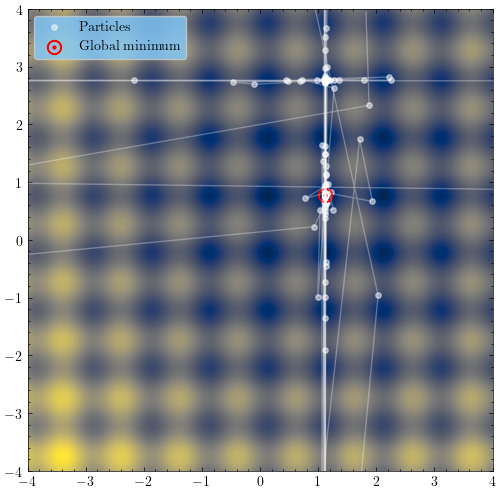

In [298]:
from cbx.plotting import PlotDynamicHistory
import scienceplots
plt.style.use('science')
fig, ax = plt.subplots(1,1, figsize=(6,6))

rot, noise = True, 'CBS'
dyn_plot = dyn_RF
pl = PlotDynamicHistory(
    dyn_plot, objective_args={'x_min':-4, 'x_max':4, 'cmap':'cividis','levels':150, 'num_pts':200},
    ax=ax)
pl.plot_objective()
x = np.array(dyn_plot.history['x'])
ts = np.arange(30, x.shape[0], 3)
ps = np.arange(30, x.shape[0], 3)
for i in range(N): 
    plt.plot(x[ps,0,i,0], x[ps,0,i,1], color='w', alpha=0.3)
    plt.scatter(x[ts,0,i,0], x[ts,0,i,1], color='w', alpha=0.5, s=15, label='Particles' if i == 0 else None)

glob_min = np.linalg.pinv(Q) @ f.Q @ f.f.b
plt.scatter(glob_min[0], glob_min[1], color='red', label='Global minimum', marker='$\odot$', s=100)
plt.legend(frameon=True, facecolor='xkcd:sky')

In [16]:
dyn_RN = RotNoiseCBO(f, x=x0.copy(), Q = Q, **ckwargs | {'sigma' : 5., 'seed': 2, 'max_it':100}, noise = 'anisotropic')
dyn_RN.optimize()
print_summary(dyn_RN)

Finished with energy  [[0.00117959]]


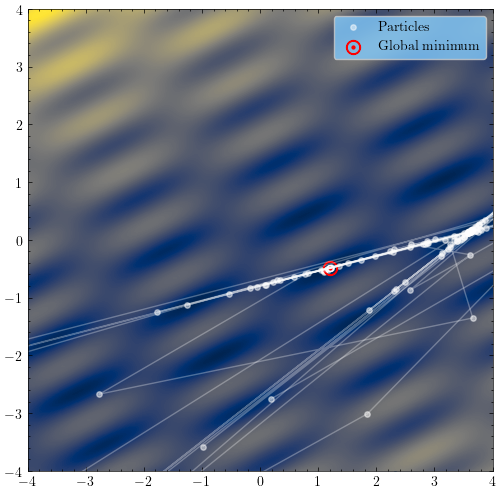

In [17]:
from cbx.plotting import PlotDynamicHistory
import scienceplots
plt.style.use('science')
fig, ax = plt.subplots(1,1, figsize=(6,6))

dyn_plot = dyn_RN
pl = PlotDynamicHistory(
    dyn_plot, objective_args={'x_min':-4, 'x_max':4, 'cmap':'cividis','levels':150, 'num_pts':200},
    ax=ax)
pl.plot_objective()
x = np.array(dyn_plot.history['x'])
ts = np.arange(30, x.shape[0], 3)
ps = np.arange(30, x.shape[0], 3)
for i in range(N): 
    plt.plot(x[ps,0,i,0], x[ps,0,i,1], color='w', alpha=0.3)
    plt.scatter(x[ts,0,i,0], x[ts,0,i,1], color='w', alpha=0.5, s=15, label='Particles' if i == 0 else None)

glob_min = P.minimum
plt.scatter(glob_min[0], glob_min[1], color='red', label='Global minimum', marker='$\odot$', s=100)
plt.legend(frameon=True, facecolor='xkcd:sky')

In [431]:
CBO_split_kwargs = {
    'dt':0.01, 'sigma':3.1, 'max_it':40,
    'noise': 'anisotropic',
    'track_args': {'names':['best_energy']},
    'alpha':1., 'verbosity':0, 'f_dim': '3D',
    'seed':2
}
dyn_SD = SplitDimCBO(d = d, CBO_kwargs=CBO_split_kwargs)
x = dyn_SD(f, Q = Q, parallel=True, x0 = x0.copy())
print('Finsihed with energy: ', f(x))
print('Distance to minimizer: ', 
      np.linalg.norm(P.minimum - x, ord=np.inf)
      )

Finsihed with energy:  8.088791524585304e-06
Distance to minimizer:  0.0005070996981630937
